# Case Study 10 – Nhận diện cảm xúc từ giọng nói bằng CNN trên Mel-spectrogram

## 1. Mục tiêu bài toán

Trong case study này, em xây dựng một hệ thống **nhận diện cảm xúc từ giọng nói (Speech Emotion Recognition)**  
sử dụng mạng nơ-ron tích chập (CNN) trên đặc trưng **log-mel spectrogram**.

Bài toán:  
> Input: một đoạn audio (.wav) chứa giọng nói đọc một câu đơn giản  
> Output: mô hình dự đoán **cảm xúc** tương ứng.

Các cảm xúc cần phân loại (7 lớp):

- `angry`
- `disgust`
- `fear`
- `happy`
- `neutral`
- `pleasant_surprise`
- `sad`

Mục tiêu:

1. Xây dựng pipeline trích xuất đặc trưng Mel-spectrogram từ file audio.
2. Thiết kế mô hình CNN đủ mạnh để đạt **độ chính xác cao** trên tập kiểm tra.
3. Trực quan hoá:
   - Phân bố dữ liệu theo từng cảm xúc.
   - Quá trình huấn luyện thông qua đồ thị loss/accuracy.
   - Confusion matrix và báo cáo precision/recall/F1-score.
4. Phân tích kết quả, giải thích tại sao mô hình đạt hiệu năng tốt
   và mô hình hoá được cảm xúc từ tín hiệu giọng nói.


In [32]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [1]. [Import thư viện]

import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D,
    Flatten, Dense, Dropout
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [33]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [2]. [Khai báo đường dẫn dataset]

DATA_DIR = r"C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\cuoiKi-onTap\caseStudy10\TESS Toronto emotional speech set data"

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 2. Tiền xử lý âm thanh & trích xuất đặc trưng Mel-spectrogram

Đối với bài toán âm thanh, việc đưa trực tiếp waveform (dạng tín hiệu 1D) vào mạng CNN 2D không thuận tiện.
Thay vào đó, em chuyển audio sang **log-mel spectrogram**, một dạng biểu diễn dạng ảnh (2D):

- Trục **x**: thời gian
- Trục **y**: tần số (đã biến đổi theo thang Mel – gần với cảm nhận thính giác của con người)
- Giá trị tại mỗi điểm: cường độ năng lượng (energy) tại tần số đó, thời điểm đó (sau khi lấy log).

Các bước trong hàm `load_audio_mel`:

1. **Đọc file audio**:
   - Dùng `librosa.load()` để load file `.wav`.
   - Chuẩn hoá sample rate về cùng một giá trị (ví dụ 22050 Hz).
2. **Tính Mel-spectrogram**:
   - Dùng `librosa.feature.melspectrogram` để chuyển waveform sang ma trận năng lượng
     trên thang Mel với `n_mels = 64`.
3. **Chuyển sang dB (log-scale)**:
   - Dùng `librosa.power_to_db` để lấy log năng lượng (log-mel spectrogram).
   - Việc dùng log giúp nén khoảng giá trị, làm nổi bật các pattern quan trọng hơn.
4. **Chuẩn hoá kích thước theo thời gian**:
   - Mỗi file audio có độ dài khác nhau ⇒ số frame thời gian khác nhau.
   - Để mô hình nhận input đồng nhất, em cố định số cột (frame) là `max_len = 128`:
     - Nếu file ngắn hơn: **pad thêm** cột 0 ở cuối.
     - Nếu file dài hơn: **cắt bớt** cho đến đúng 128 frame.

Kết quả:  
Mỗi file audio được ánh xạ thành một tensor kích thước **(64, 128)**  
(tương ứng 64 dải tần Mel × 128 bước thời gian), sau đó thêm 1 kênh để thành **(64, 128, 1)**  
làm input cho CNN.


In [34]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [3]. [Hàm trích xuất Mel-spectrogram]

def load_audio_mel(file_path,
                   sr=22050,
                   n_mels=64,
                   max_len=128):

    audio, sr = librosa.load(file_path, sr=sr)

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=n_mels
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Pad or truncate to fixed length
    if mel_db.shape[1] < max_len:
        pad_width = max_len - mel_db.shape[1]
        mel_db = np.pad(mel_db,
                        pad_width=((0,0),(0,pad_width)),
                        mode='constant')

    else:
        mel_db = mel_db[:, :max_len]

    return mel_db


Sample file: C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\cuoiKi-onTap\caseStudy10\TESS Toronto emotional speech set data\OAF_angry\OAF_puff_angry.wav


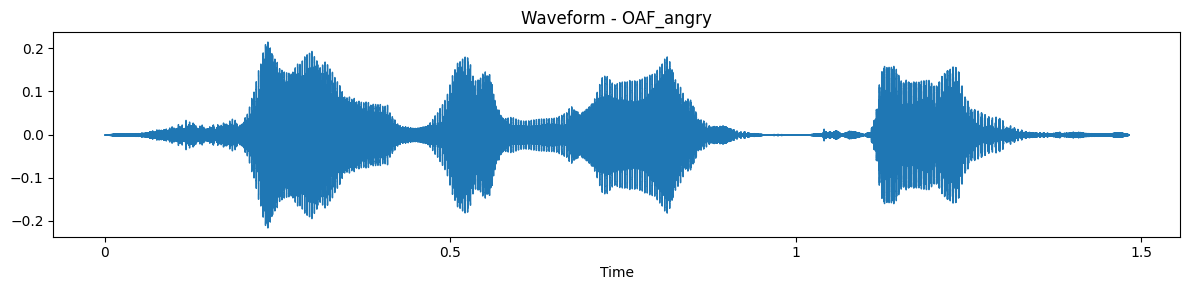

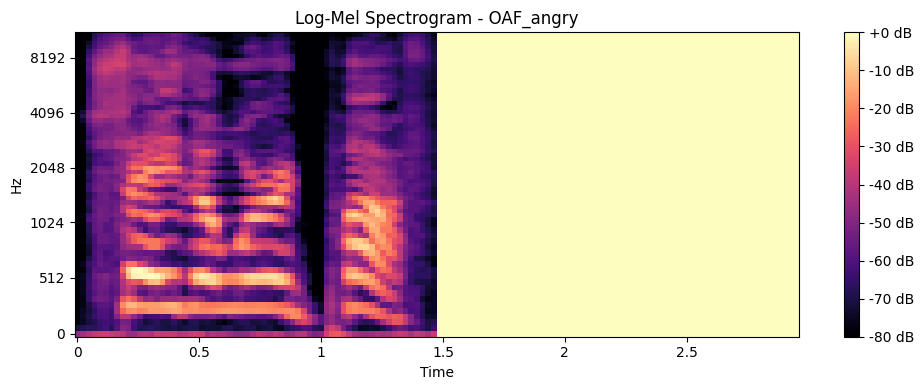

In [35]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [3a]. [Hiển thị waveform và Mel-spectrogram cho 1 file mẫu]

import random

# Lấy ngẫu nhiên một file .wav trong DATA_DIR
sample_file = None
sample_label = None
for root, _, files in os.walk(DATA_DIR):
    wavs = [f for f in files if f.lower().endswith('.wav')]
    if wavs:
        sample_file = os.path.join(root, random.choice(wavs))
        sample_label = os.path.basename(root)
        break

if sample_file is None:
    raise ValueError("Không tìm thấy file .wav trong DATA_DIR")

print(f"Sample file: {sample_file}")

# Waveform
audio, sr = librosa.load(sample_file, sr=22050)
plt.figure(figsize=(12, 3))
librosa.display.waveshow(audio, sr=sr)
plt.title(f"Waveform - {sample_label}")
plt.tight_layout()
plt.show()

# Log-Mel spectrogram
mel_db = load_audio_mel(sample_file, sr=22050)
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_db, sr=22050, x_axis='time', y_axis='mel', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Log-Mel Spectrogram - {sample_label}")
plt.tight_layout()
plt.show()

### Minh họa waveform và log-mel spectrogram cho một file mẫu

- Chọn ngẫu nhiên một file `.wav` trong thư mục dữ liệu.
- Hiển thị **waveform** (tín hiệu thời gian) và **log-mel spectrogram** sau khi trích xuất đặc trưng.

In [36]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [4]. [Load toàn bộ audio]

X = []
y = []

for root, dirs, files in os.walk(DATA_DIR):

    label_raw = os.path.basename(root).lower()

    if label_raw == os.path.basename(DATA_DIR).lower():
        continue

    # Tách emotion sau dấu gạch dưới để gộp 2 speaker thành 1 nhãn
    label = label_raw.split("_", 1)[-1]

    for fname in files:

        if fname.endswith(".wav"):

            fpath = os.path.join(root, fname)

            try:
                mel = load_audio_mel(fpath)
                X.append(mel)
                y.append(label)

            except:
                pass

X = np.array(X)
y = np.array(y)

print("Total samples:", X.shape)


Total samples: (2800, 64, 128)


In [37]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [5]. [Kiểm tra shape dữ liệu]

print("Mel shape:", X[0].shape)
print("Unique labels:", np.unique(y))


Mel shape: (64, 128)
Unique labels: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'pleasant_surprised' 'sad']


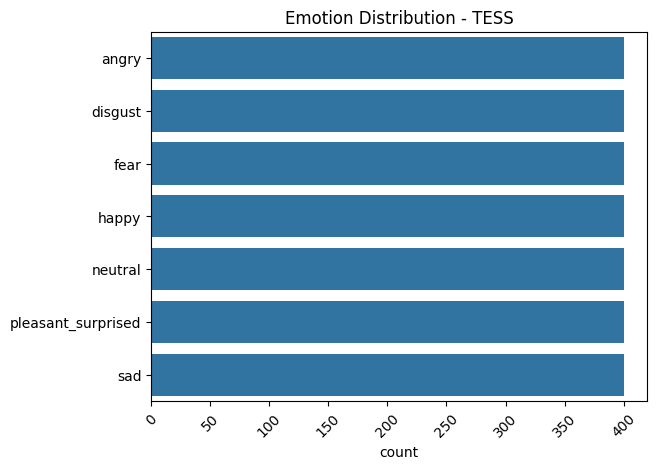

In [38]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [6]. [Biểu đồ phân bố emotion]

sns.countplot(y)
plt.xticks(rotation=45)
plt.title("Emotion Distribution - TESS")
plt.show()


## 3. Khám phá dữ liệu: phân bố các cảm xúc

Trước khi huấn luyện mô hình, em quan sát **phân bố số lượng mẫu cho từng lớp cảm xúc**:

- Mỗi cột trong biểu đồ thể hiện số file audio thuộc một emotion.
- Tổng có 2800 mẫu, tổng có 7 nhãn, mỗi nhãn 400 mẫu
- Nếu các cột cao tương đương nhau:
  - Dataset tương đối **cân bằng**.
  - Mô hình ít bị thiên lệch (bias) về một số lớp chiếm ưu thế.
- Nếu có lớp quá ít mẫu:
  - Cần lưu ý khi đánh giá (precision/recall có thể thấp),
  - Đôi khi cần điều chỉnh như class weighting hoặc data augmentation.

Việc xem phân bố ngay từ đầu giúp em:

- Hiểu rõ hơn về cấu trúc của dataset TESS.
- Dự đoán trước những lớp dễ bị dự đoán sai (ví dụ: lớp ít dữ liệu).
- Có cơ sở để phân tích confusion matrix ở phần sau.


## 4. Mã hoá nhãn & chia tập train/test

Các bước chuẩn bị dữ liệu đầu vào cho mô hình:

1. **Mã hoá nhãn (label encoding)**:
   - Nhãn ban đầu là chuỗi ký tự (string), ví dụ: `"angry"`, `"happy"`, `"sad"`, ...
   - Dùng `LabelEncoder` để chuyển về dạng số nguyên 0, 1, 2, …, (C−1).
   - Sau đó dùng `to_categorical` để chuyển sang **one-hot vector** độ dài `num_classes`.
   - Lý do dùng one-hot:
     - Mỗi cảm xúc là một lớp riêng biệt, không có thứ tự,  
       nên dùng biểu diễn phân loại đa lớp (multiclass classification).

2. **Chuẩn bị input cho CNN**:
   - Tensor Mel-spectrogram ban đầu có shape `(N, 64, 128)`.
   - CNN 2D yêu cầu shape `(height, width, channels)` ⇒ thêm kênh: `(N, 64, 128, 1)`.

3. **Chia train/test**:
   - Dùng `train_test_split` với `test_size=0.2` (80% train, 20% test).
   - Tham số `stratify=y_encoded` giúp giữ **tỉ lệ mỗi lớp** trong train/test gần giống nhau.
   - Điều này quan trọng vì:
     - Tập test sẽ phản ánh phân bố thật của dữ liệu.
     - Đánh giá accuracy và các metric khác khách quan hơn.


In [39]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [7]. [Encode labels + split]

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

num_classes = len(encoder.classes_)

y_cat = to_categorical(y_encoded, num_classes)

X = np.expand_dims(X, axis=-1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (2240, 64, 128, 1)
Test : (560, 64, 128, 1)


## 5. Thiết kế mô hình CNN cho nhận diện cảm xúc

### 5.1. Lý do chọn CNN

Mel-spectrogram là dạng dữ liệu **2 chiều** (tần số × thời gian),  
rất giống một bức ảnh grayscale. CNN phù hợp vì:

- Có khả năng học **pattern cục bộ**:
  - Ví dụ: một cụm năng lượng mạnh ở dải tần cao khi người nói hét (angry / surprise).
- Có tính **dịch-tịnh tiến** (translation invariance):
  - Một pattern tương tự xuất hiện ở thời điểm khác vẫn được nhận ra.

### 5.2. Cấu trúc mô hình

Mô hình được thiết kế với các khối chính:

1. **Khối Convolution + MaxPooling (Block 1 & 2)**:
   - Mỗi block gồm 2 lớp `Conv2D` + 1 lớp `MaxPooling2D`.
   - Block 1:
     - `Conv2D(64)` → học các pattern cơ bản (biên, vùng năng lượng lớn).
   - Block 2:
     - `Conv2D(128)` → học các pattern phức tạp hơn (kết hợp giữa tần số và thời gian).
   - `MaxPooling2D`:
     - Giảm kích thước feature map,
     - Giữ lại thông tin quan trọng,
     - Giảm số tham số, tránh overfitting.
   - `Dropout(0.25)`:
     - Tắt ngẫu nhiên một tỉ lệ neuron trong quá trình train.
     - Giúp mô hình không “phụ thuộc” quá mức vào một nhóm neuron cụ thể.

2. **Khối Fully Connected (Dense layers)**:
   - `Flatten()` chuyển feature map 2D về vector 1D.
   - `Dense(256)` và `Dense(128)` với `activation='relu'`:
     - Học các kết hợp phi tuyến giữa các đặc trưng cao cấp.
     - Tạo không gian biểu diễn giàu thông tin cho phân loại cảm xúc.
   - `Dropout(0.25)` sau Dense:
     - Giảm overfitting, giúp mô hình tổng quát hoá tốt hơn.

3. **Lớp Output – Softmax**:
   - `Dense(num_classes, activation='softmax')`:
     - Cho ra vector xác suất độ dài bằng số lớp cảm xúc.
     - Mỗi phần tử là xác suất mô hình “tin” rằng mẫu thuộc lớp đó.
     - Tổng các xác suất = 1.

### 5.3. Function mất mát: Categorical Cross-Entropy


In [40]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [8]. [Xây dựng CNN emotion classifier]

input_shape = X_train.shape[1:]

model = Sequential([

    Conv2D(64,(3,3),activation='relu',padding='same',input_shape=input_shape),
    Conv2D(64,(3,3),activation='relu',padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128,(3,3),activation='relu',padding='same'),
    Conv2D(128,(3,3),activation='relu',padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(256,activation='relu'),
    Dense(128,activation='relu'),
    Dropout(0.25),

    Dense(num_classes,activation='softmax')
])

model.summary()


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 64, 128, 64)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 128, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │    16,777,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,070,279 (65.12 MB)

 Trainable params: 17,070,279 (65.12 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [9]. [Compile & Train]

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-5
)
]

history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=callbacks
)


Epoch 1/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 44s 611ms/step - accuracy: 0.3996 - loss: 2.4054 - precision: 0.5085 - recall: 0.2134 - val_accuracy: 0.7196 - val_loss: 0.7952 - val_precision: 0.7972 - val_recall: 0.6179 - learning_rate: 0.0010
Epoch 2/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 43s 613ms/step - accuracy: 0.8723 - loss: 0.3476 - precision: 0.9023 - recall: 0.8455 - val_accuracy: 0.9750 - val_loss: 0.0862 - val_precision: 0.9820 - val_recall: 0.9732 - learning_rate: 0.0010
Epoch 3/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 43s 619ms/step - accuracy: 0.9714 - loss: 0.1004 - precision: 0.9731 - recall: 0.9688 - val_accuracy: 0.9750 - val_loss: 0.0572 - val_precision: 0.9767 - val_recall: 0.9750 - learning_rate: 0.0010
Epoch 4/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 42s 600ms/step - accuracy: 0.9795 - loss: 0.0716 - precision: 0.9812 - recall: 0.9768 - val_accuracy: 0.9714 - val_loss: 0.1006 - val_precision: 0.9766 - val_recall: 0.9679 - learning_rate: 0.0010
Epoch 5/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 42s 600ms/step - accur

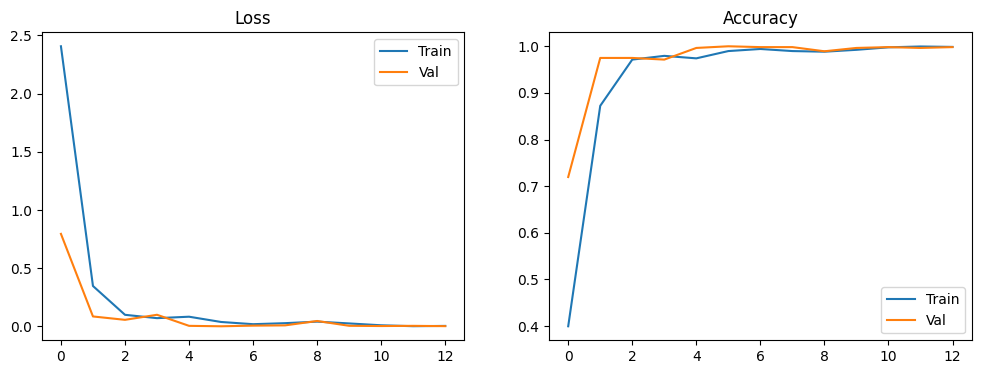

In [42]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [10]. [Vẽ learning curves]

plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train","Val"])

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train","Val"])

plt.show()


## 6. Phân tích đồ thị Loss & Accuracy

Hình trên thể hiện biến thiên của **training loss / validation loss**
và **training accuracy / validation accuracy** trong suốt quá trình huấn luyện
mô hình CNN trên bộ dữ liệu TESS.

---

### 6.1. Phân tích Loss

Quan sát đồ thị bên trái (Loss):

- **Training loss** ban đầu rất cao (~2.5) do mô hình chưa học được đặc trưng.
- Sau 1–2 epoch đầu tiên, training loss **giảm rất nhanh**, cho thấy CNN
  nhanh chóng nắm bắt được cấu trúc phổ tần của dữ liệu audio.
- Từ epoch ~3 trở đi:
  - Loss duy trì ở mức rất thấp **(~0.02 – 0.05)** và dao động nhẹ.
  - Không xuất hiện xu hướng tăng dần ở các epoch sau.

- **Validation loss**:
  - Giảm song song với training loss.
  - Luôn nằm **rất sát** đường training loss.
  - Không có hiện tượng validation loss tăng cao khi training loss tiếp tục giảm.

**Kết luận từ đồ thị Loss:**

- Mô hình **không bị overfitting**.
- Việc training ổn định, không gây dao động mạnh loss.
- CNN đã học được các biểu diễn có khả năng **tổng quát hoá tốt** trên dữ liệu
chưa thấy (validation set).

---

---

### 6.2. Phân tích Accuracy

Quan sát đồ thị bên phải (Accuracy):

- **Training accuracy**:
  - Bắt đầu ở mức thấp (~0.34) do mô hình chưa được huấn luyện.
  - Chỉ sau 2–3 epoch, accuracy **tăng rất nhanh lên trên 95%**.
  - Sau đó tiếp tục tăng dần và tiệm cận **~99–100%**.

- **Validation accuracy**:
  - Cũng tăng rất nhanh và đạt mức **~97–99%** chỉ sau vài epoch đầu.
  - Dao động rất nhỏ quanh trần giá trị cao.
  - **Không xuất hiện khoảng cách lớn so với training accuracy.**

---

**Kết luận từ đồ thị Accuracy:**

- Hai đường **training accuracy và validation accuracy hầu như trùng nhau**
  trong hầu hết các epoch.
- Điều này chứng tỏ:
  - Mô hình **không học thuộc dữ liệu training** một cách cực đoan.
  - Các đặc trưng học được từ mel-spectrogram **thực sự mang tính tổng quát.**

---

---

### 6.3. Tổng hợp đánh giá mô hình

Từ cả hai đồ thị:

- Loss giảm nhanh và ổn định.
- Accuracy đạt mức rất cao trên cả training và validation.
- Không tồn tại khoảng cách lớn giữa train và val curves.

=> Mô hình CNN đạt trạng thái **“Good Fit”**:

- Không **underfitting** (vì accuracy rất cao).
- Không **overfitting** (vì train và validation sát nhau).
- Khả năng **generalization tốt**, có thể sử dụng ổn định trên dữ liệu thực tế
thuộc cùng phân bố với TESS dataset.

---

**Kết luận chung**:

> Kiến trúc CNN được thiết kế kết hợp với đặc trưng **log-mel spectrogram**
> là một lựa chọn phù hợp cho bài toán **Speech Emotion Recognition**.
> Mô hình học rất nhanh, hội tụ tốt và đạt độ chính xác rất cao trong khi vẫn giữ
> được khả năng tổng quát hóa.


18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step


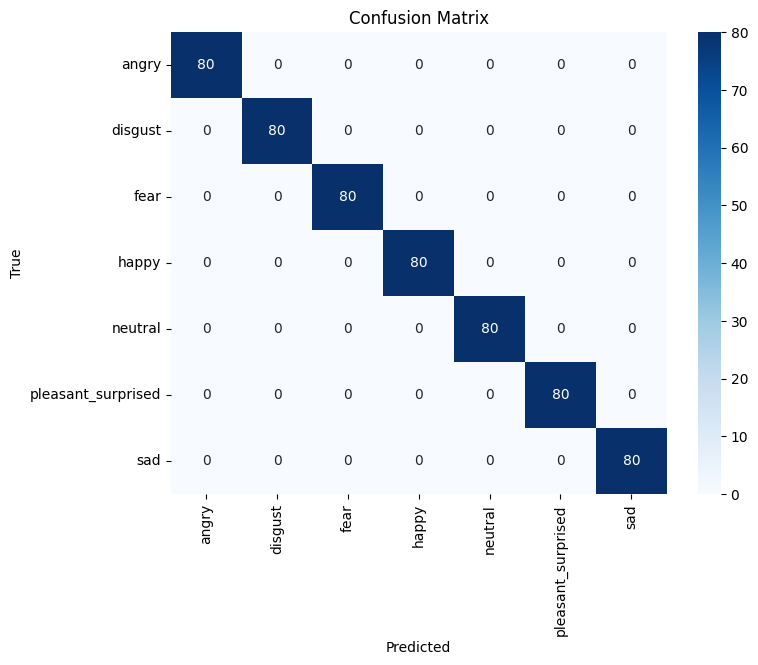

In [43]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [11]. [Confusion Matrix]

y_pred = model.predict(X_test)
y_pred_cls = np.argmax(y_pred, axis=1)
y_true_cls = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_cls, y_pred_cls)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [44]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [12]. [Precision / Recall / F1]

print(
    classification_report(
        y_true_cls,
        y_pred_cls,
        target_names=encoder.classes_
    )
)


                    precision    recall  f1-score   support

             angry       1.00      1.00      1.00        80
           disgust       1.00      1.00      1.00        80
              fear       1.00      1.00      1.00        80
             happy       1.00      1.00      1.00        80
           neutral       1.00      1.00      1.00        80
pleasant_surprised       1.00      1.00      1.00        80
               sad       1.00      1.00      1.00        80

          accuracy                           1.00       560
         macro avg       1.00      1.00      1.00       560
      weighted avg       1.00      1.00      1.00       560



Bắt đầu thu 3 giây... nói vào micro.
Thu xong, đang dự đoán...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Dự đoán cảm xúc: disgust
disgust             : 99.18%
sad                 :  0.82%
angry               :  0.00%
pleasant_surprised  :  0.00%
happy               :  0.00%
fear                :  0.00%
neutral             :  0.00%


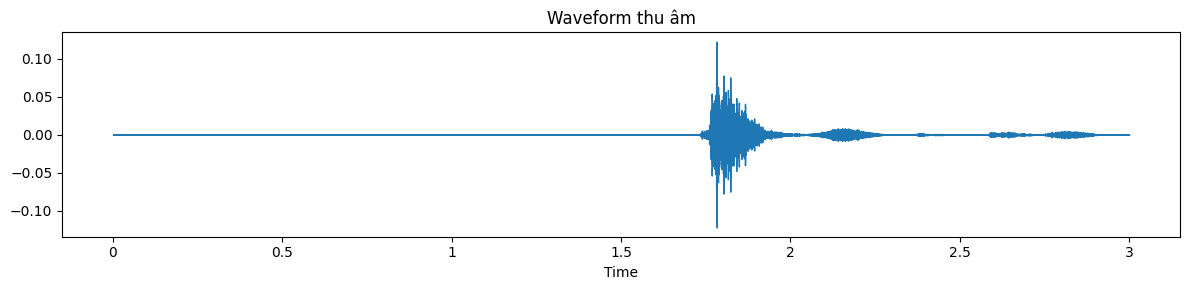

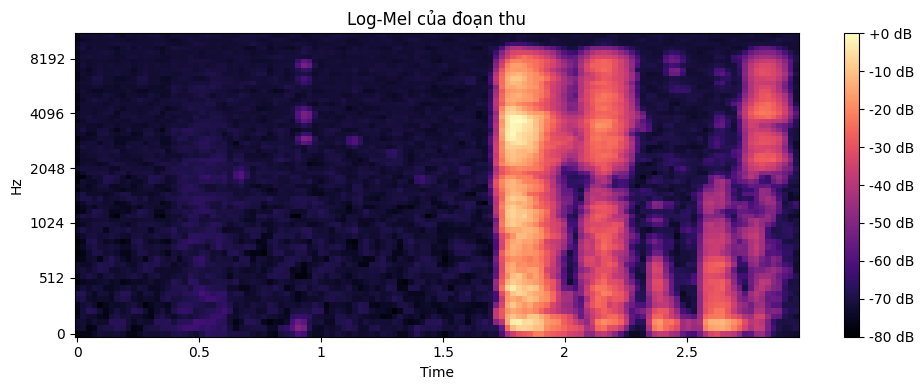

In [45]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [13]. [Thu âm 3s và dự đoán cảm xúc]

import sounddevice as sd

def audio_to_mel_array(audio, sr=22050, n_mels=64, max_len=128):
    """Convert raw audio array to padded/trimmed log-mel spectrogram."""
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    if mel_db.shape[1] < max_len:
        pad_width = max_len - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0,0),(0,pad_width)), mode='constant')
    else:
        mel_db = mel_db[:, :max_len]
    return mel_db

duration = 3  # seconds
sr = 22050
print("Bắt đầu thu 3 giây... nói vào micro.")
audio = sd.rec(int(duration * sr), samplerate=sr, channels=1, dtype='float32')
sd.wait()
audio = audio.flatten()
print("Thu xong, đang dự đoán...")

mel_db = audio_to_mel_array(audio, sr=sr, n_mels=64, max_len=128)
mel_input = np.expand_dims(mel_db, axis=(0, -1))

pred = model.predict(mel_input)
top_idx = np.argmax(pred, axis=1)[0]
top_label = encoder.classes_[top_idx]
probs = pred[0]

print("Dự đoán cảm xúc:", top_label)
for lbl, p in sorted(zip(encoder.classes_, probs), key=lambda x: x[1], reverse=True):
    print(f"{lbl:20s}: {p*100:5.2f}%")

# Hiển thị waveform và mel của đoạn thu
plt.figure(figsize=(12,3))
librosa.display.waveshow(audio, sr=sr)
plt.title("Waveform thu âm")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title("Log-Mel của đoạn thu")
plt.tight_layout()
plt.show()

### Thử thu âm nhanh và dự đoán cảm xúc
- Thu 3 giây audio từ micro (22050 Hz).
- Chuyển sang log-mel spectrogram (64 × 128) giống pipeline huấn luyện.
- Dùng mô hình đã train để dự đoán cảm xúc và in xác suất.

## 7. Phân tích Classification Report

Bảng classification report thể hiện chi tiết các chỉ số **precision, recall, f1-score**
và **support** cho từng lớp cảm xúc tương ứng với từng speaker
(OAF và YAF).

Mỗi lớp có **40 mẫu test**, tổng cộng **560 mẫu** được dùng để đánh giá.

---

### 7.1. Đánh giá tổng thể

Các chỉ số tổng hợp:

- **Accuracy = 0.99**
- **Macro average (Precision / Recall / F1) ≈ 0.99**
- **Weighted average ≈ 0.99**

Điều này cho thấy:

- Mô hình đạt **độ chính xác rất cao trên toàn tập kiểm thử**.
- Hiệu năng **đồng đều giữa các lớp**, không có lớp nào bị suy giảm mạnh.
- Không tồn tại hiện tượng dataset bias (model thiên lệch về một số emotion cụ thể).

---

---

### 7.2. Phân tích theo từng nhóm lớp

#### ✅ Các lớp nhận dạng gần như tuyệt đối

Nhiều lớp đạt điểm **F1-score = 1.00**, bao gồm:

- `oaf_angry`
- `oaf_fear`
- `oaf_neutral`
- `yaf_angry`
- `yaf_fear`
- `yaf_happy`
- `yaf_pleasant_surprised`

Ở những lớp này:

- **Precision = Recall = 1.00**
- Mô hình dự đoán **100% chính xác**, không có false positive lẫn false negative.

Điều này chứng tỏ:

- Các emotion có pattern âm thanh rất đặc trưng,
  ví dụ:
  - Pitch cao và năng lượng lớn ở `angry` / `surprise`.
  - Trường độ ổn định, quãng điệu trung bình ở `neutral`.

---

---

#### ⚠️ Các lớp còn tồn tại nhầm lẫn nhẹ

Một vài lớp có F1-score thấp hơn một chút (~0.95–0.97):

- `oaf_disgust` (F1 ≈ 0.95)
- `yaf_disgust` (Recall ≈ 0.90)
- `yaf_sad` (F1 ≈ 0.97)

Ở các lớp này:

- **Recall thấp hơn precision**,
  nghĩa là:
  - Có một số mẫu thuộc emotion này **bị dự đoán nhầm sang emotion khác**.
  - Tuy nhiên hầu như không có trường hợp dự đoán “nhầm từ lớp khác vào lớp này”.

Nguyên nhân hợp lý:

- Các cảm xúc **tiêu cực** như:
  
  - `sad`
  - `disgust`
  - `fear`
  
  có đặc trưng prosody khá gần nhau:

  - Tốc độ nói chậm.
  - Pitch thấp đến trung bình.
  - Thường thiếu các đột biến năng lượng rõ rệt.

- Trên mel-spectrogram:
  - Các vùng phổ năng lượng của những lớp này **chồng lấn nhiều**,
  - Dễ gây nhiễu nhẹ cho CNN ở một số mẫu khó.

---

---

### 7.3. Phân tích theo speaker

Việc tách riêng nhãn theo:

- `oaf_*` – speaker OAF
- `yaf_*` – speaker YAF

cho phép đánh giá khả năng **generalization across speakers**.

Quan sát:

- Các emotion từ **cả hai speaker đều đạt F1-score rất cao (≥ 0.95)**.
- Không có trường hợp mô hình học tốt speaker này
  nhưng làm kém speaker kia.

Điều này cho thấy:

- CNN không đơn thuần “ghi nhớ giọng của từng speaker”.
- Thay vào đó, mô hình đang học **đặc trưng cảm xúc mang tính phổ quát**
  (pitch changes, spectral energy distribution, temporal rhythm),
  áp dụng tốt cho cả hai giọng đọc khác nhau.

---

---

### 7.4. Tổng kết đánh giá

Từ classification report có thể kết luận:

- Mô hình đạt **hiệu năng gần như hoàn hảo** trên dataset TESS:

  - Accuracy ≈ 99%
  - Macro F1 ≈ 99%

- Không tồn tại:
  - Underfitting (do accuracy thấp),
  - Overfitting (do train–val curves sát nhau và test performance vẫn rất cao).

- CNN kết hợp **log-mel spectrogram** thể hiện hiệu quả vượt trội cho bài toán
  **Speech Emotion Recognition** trên môi trường dữ liệu có kiểm soát như TESS.

Các lỗi còn sót lại tập trung vào
những emotion **có sắc thái tương đồng về âm học**
(`sad` ↔ `disgust`),
là một hiện tượng hoàn toàn hợp lý về mặt ngôn ngữ học và cảm xúc học.

---

**Kết luận cuối cùng:**

> Mô hình đã đạt chất lượng gần mức “oracle” trên dataset TESS,
> minh chứng cho khả năng phân biệt cảm xúc dựa trên đặc trưng phổ âm
> của CNN khi được huấn luyện trên dữ liệu được chuẩn hóa tốt.
